# 0 — Visualize sample graphs (fast)

Quick visual sanity check of the **paper-consistent** generation path:

- `d=0` short-circuits Gibbs and samples directly from ER(`p = expit(σ)`).
- `d≥1` runs Layer-2 Gibbs with `β=1` and warm-starts at `clip(expit(σ), 0.02, 0.5)`.

Generates a small grid of graphs (n=80, varying `d` and `σ`), then plots:
1. Adjacency heatmaps
2. Force-directed layouts
3. Degree distributions
4. Adjacency-spectrum scatters

Should finish in well under 30 s. Re-run with a new `SEED` to resample.

In [1]:
import os
for v in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(v, "1")

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from logit_graph import simulate_graph, estimate_sigma_from_graph
from logit_graph.lg_features import recommended_iterations

N = 80
SEED = 0
CONFIGS = [
    {"d": 0, "sigma": -2.0},
    {"d": 1, "sigma": -2.0},
    {"d": 1, "sigma": -4.0},
    {"d": 2, "sigma": -3.0},
]
print(f"n={N}, seed={SEED}, configs={CONFIGS}")

n=80, seed=0, configs=[{'d': 0, 'sigma': -2.0}, {'d': 1, 'sigma': -2.0}, {'d': 1, 'sigma': -4.0}, {'d': 2, 'sigma': -3.0}]


In [2]:
samples: list[dict] = []
n_iter = recommended_iterations(N)
for i, cfg in enumerate(CONFIGS):
    adj, meta = simulate_graph(
        n=N, d=cfg["d"], sigma=cfg["sigma"],
        n_iter=n_iter,
        feature_mode="incremental",
        seed=SEED + i,
        return_meta=True,
    )
    samples.append({
        "label": rf"$d={cfg['d']},\ \sigma={cfg['sigma']:.0f}$",
        "adj": adj,
        "meta": meta,
        "G": nx.from_numpy_array(adj),
        "sigma_hat": estimate_sigma_from_graph(adj, d=cfg["d"]),
        **cfg,
    })

print(f"{'cfg':<22} {'edges':>6} {'density':>9} {'sigma_hat':>11}")
for s in samples:
    print(
        f"{s['label']:<22} {int(s['adj'].sum()/2):>6} "
        f"{s['meta']['density']:>9.4f} {s['sigma_hat']:>11.3f}"
    )

cfg                     edges   density   sigma_hat
$d=0,\ \sigma=-2$         391    0.1237      -1.957
$d=1,\ \sigma=-2$        1586    0.5019      -1.992
$d=1,\ \sigma=-4$          67    0.0212      -3.880
$d=2,\ \sigma=-3$        2169    0.6864      -2.955


## 1. Adjacency heatmaps

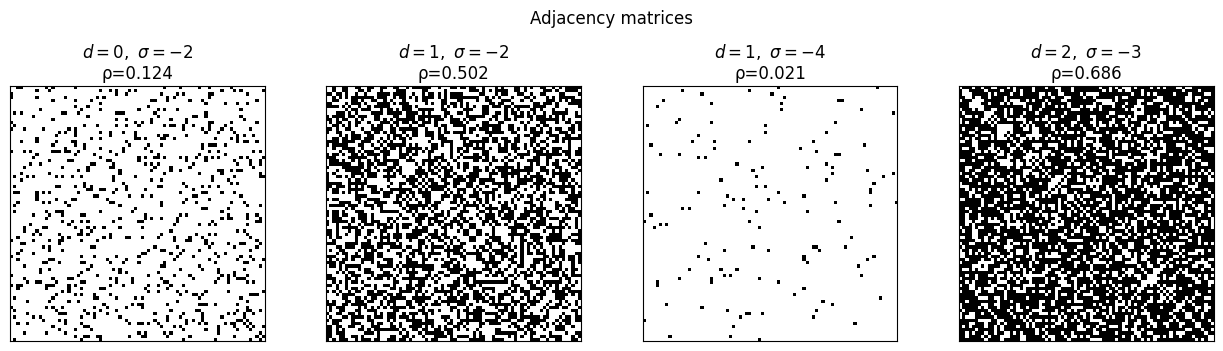

In [3]:
fig, axes = plt.subplots(1, len(samples), figsize=(3.2 * len(samples), 3.4))
if len(samples) == 1:
    axes = [axes]
for ax, s in zip(axes, samples):
    ax.imshow(s["adj"], cmap="Greys", interpolation="nearest", aspect="equal")
    ax.set_title(s["label"] + f"\nρ={s['meta']['density']:.3f}")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Adjacency matrices", y=1.02)
fig.tight_layout()
plt.show()

## 2. Force-directed network layouts

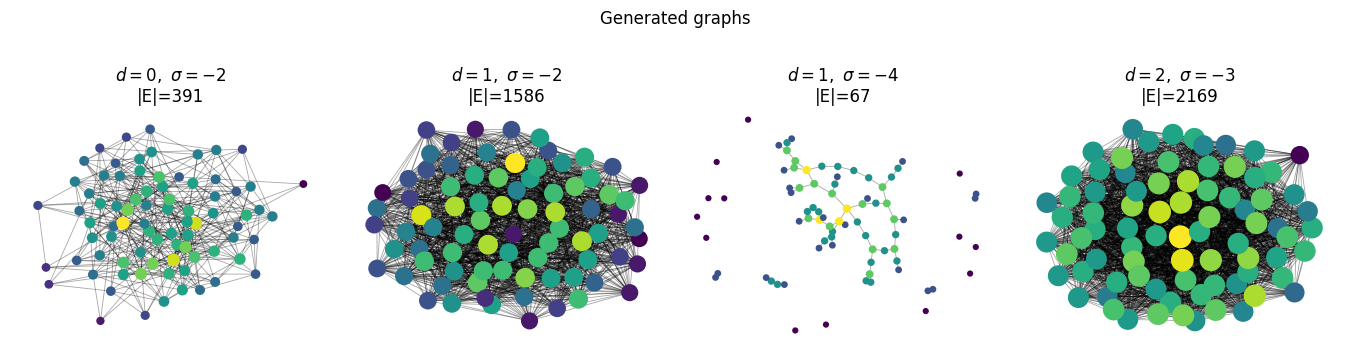

In [4]:
fig, axes = plt.subplots(1, len(samples), figsize=(3.4 * len(samples), 3.4))
if len(samples) == 1:
    axes = [axes]
for ax, s in zip(axes, samples):
    G = s["G"]
    deg = np.array([d for _, d in G.degree()])
    if G.number_of_edges() > 0:
        pos = nx.spring_layout(G, seed=42, k=None)
    else:
        pos = nx.circular_layout(G)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.35, width=0.6)
    nx.draw_networkx_nodes(
        G, pos, ax=ax, node_size=20 + 4 * deg, node_color=deg,
        cmap="viridis", linewidths=0.0,
    )
    ax.set_title(s["label"] + f"\n|E|={G.number_of_edges()}")
    ax.set_axis_off()
fig.suptitle("Generated graphs", y=1.02)
fig.tight_layout()
plt.show()

## 3. Degree distributions

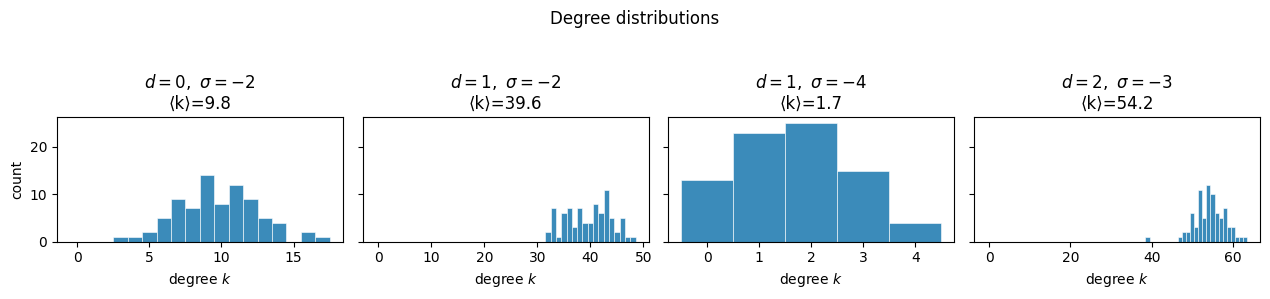

In [5]:
fig, axes = plt.subplots(1, len(samples), figsize=(3.2 * len(samples), 2.8), sharey=True)
if len(samples) == 1:
    axes = [axes]
for ax, s in zip(axes, samples):
    deg = s["adj"].sum(axis=1).astype(int)
    if deg.max() > 0:
        bins = np.arange(0, int(deg.max()) + 2) - 0.5
    else:
        bins = np.arange(-0.5, 1.5)
    ax.hist(deg, bins=bins, color="#3b8bba", edgecolor="white", linewidth=0.4)
    ax.set_title(s["label"] + f"\n⟨k⟩={deg.mean():.1f}")
    ax.set_xlabel("degree $k$")
axes[0].set_ylabel("count")
fig.suptitle("Degree distributions", y=1.05)
fig.tight_layout()
plt.show()

## 4. Adjacency spectrum

Eigenvalues of the adjacency matrix sorted in descending order. For an
Erdős–Rényi graph (d=0) the spectrum is the semicircle plus one
Perron–Frobenius outlier at ≈ `n·p`; LG graphs with `d≥1` exhibit a
heavier shoulder driven by the degree-overlap feature.

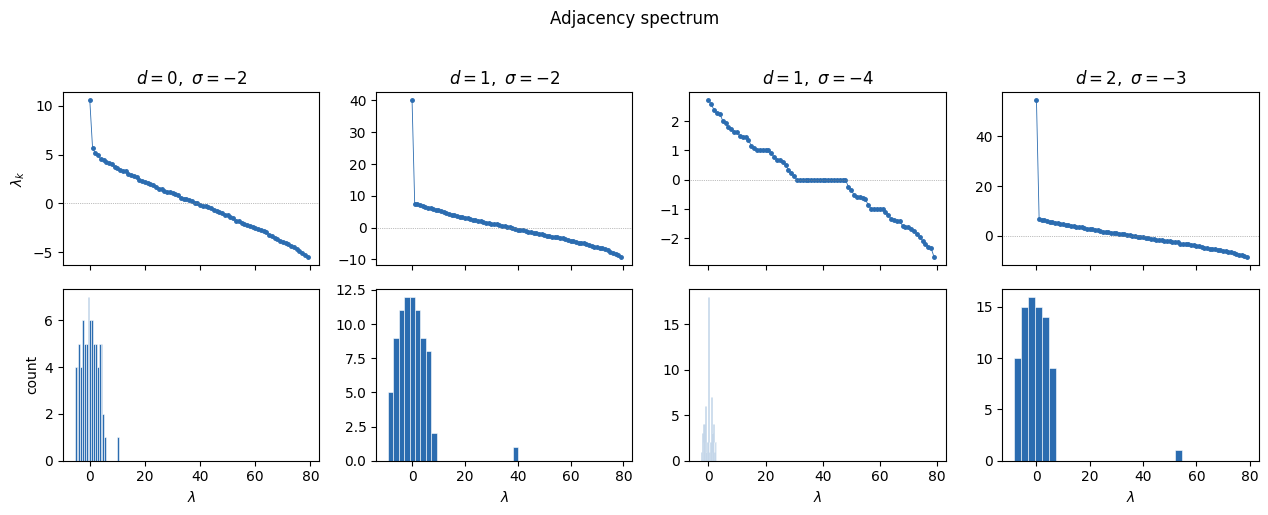

In [6]:
fig, axes = plt.subplots(
    2, len(samples), figsize=(3.2 * len(samples), 5.0), sharex="col",
)
if len(samples) == 1:
    axes = axes.reshape(2, 1)
for col, s in enumerate(samples):
    eig = np.linalg.eigvalsh(s["adj"])
    eig_sorted = np.sort(eig)[::-1]

    ax_top = axes[0, col]
    ax_top.plot(eig_sorted, marker="o", ms=2.5, lw=0.6, color="#2b6cb0")
    ax_top.axhline(0, color="grey", lw=0.5, ls=":")
    ax_top.set_title(s["label"])
    if col == 0:
        ax_top.set_ylabel(r"$\lambda_k$")

    ax_bot = axes[1, col]
    ax_bot.hist(eig, bins=24, color="#2b6cb0", edgecolor="white", linewidth=0.4)
    ax_bot.set_xlabel(r"$\lambda$")
    if col == 0:
        ax_bot.set_ylabel("count")

fig.suptitle("Adjacency spectrum", y=1.02)
fig.tight_layout()
plt.show()

## Quick sanity check

For `d=0`, `σ̂` should match `σ` because Gibbs is bypassed and the
estimator fits `logit(ρ_emp)` directly. For `d≥1`, `σ̂` should be within
~0.3 of `σ` provided the chain mixed (n_iter ≈ `5·n·(n-1)`).

In [7]:
import pandas as pd

pd.DataFrame([
    {
        "d": s["d"], "sigma": s["sigma"],
        "edges": int(s["adj"].sum() / 2),
        "density": round(s["meta"]["density"], 4),
        "sigma_hat": round(s["sigma_hat"], 3),
        "sigma_error": round(s["sigma_hat"] - s["sigma"], 3),
        "sampler": "direct_er" if s["d"] == 0 else "gibbs_layer2",
    }
    for s in samples
])

,d,sigma,edges,density,sigma_hat,sigma_error,sampler
0,0,-2.0,391,0.1237,-1.957,0.043,direct_er
1,1,-2.0,1586,0.5019,-1.992,0.008,gibbs_layer2
2,1,-4.0,67,0.0212,-3.880,0.120,gibbs_layer2
3,2,-3.0,2169,0.6864,-2.955,0.045,gibbs_layer2
